# Fitness Level Classification

## Project Overview

This project develops a multiclass machine learning workflow to classify physical fitness levels from participant characteristics and fitness test results.

The portfolio workflow covers:

**EDA → preprocessing → stratified train/test split → model pipeline → SMOTE → model comparison → cross-validation → test-set evaluation → feature importance**

The analysis compares Decision Tree, Random Forest, K-Nearest Neighbors (KNN), Logistic Regression, and XGBoost.

## Objectives

- Explore the structure and distribution of the fitness dataset.
- Prepare numerical and categorical variables for classification.
- Address class imbalance using SMOTE.
- Compare multiple classification algorithms.
- Evaluate models using Accuracy and weighted F1-score.
- Validate model performance using stratified 5-fold cross-validation.
- Inspect feature importance from the Random Forest model.

## Data Note

The original project dataset may contain participant-level information. For a public GitHub portfolio, use only an authorized and appropriately anonymized dataset.

Expected project structure:

```text
Fitness-Level-Classification/
├── README.md
├── notebook/
│   └── fitness_level_classification.ipynb
└── data/
    └── data_kebugaran.xlsx
```

If the dataset is not included in the repository, the notebook will need an authorized local copy before it can be run.

## 1. Import Libraries

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SklearnPipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    make_scorer
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

import xgboost as xgb

RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

## 2. Load Dataset

In [52]:
DATA_PATH = "/content/data kebugaran.xlsx"


df = pd.read_excel(DATA_PATH)

print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (169, 12)


,Umur,Jenis Kelamin,TB,BB,IMT,Kriteria BB,Waktu,Hasil,Frekuensi Latihan,Denyut Nadi Latihan,Lama Inti Latihan Fisik,Tipe Latihan Fisik
0,10,P,130,25.0,14.79,SANGAT KURUS,10.12,Kurang Sekali,2x/minggu,100 - 120 / Menit,20 - 30 Menit,Latihan Aerobik tipe 1
1,10,L,141,45.0,22.63,NORMAL,8.08,Kurang Sekali,2x/minggu,100 - 120 / Menit,20 - 30 Menit,Latihan Aerobik tipe 1
2,10,P,133,28.0,15.83,SANGAT KURUS,8.39,Kurang,2x/minggu,100 - 120 / Menit,20 - 30 Menit,Latihan Aerobik tipe 1
3,10,P,124,25.0,16.26,KURUS,9.02,Kurang Sekali,2x/minggu,100 - 120 / Menit,20 - 30 Menit,Latihan Aerobik tipe 1
4,10,L,127,24.0,14.88,SANGAT KURUS,5.55,Cukup,3x/minggu,120 - 140 / Menit,30 - 40 Menit,Latihan Aerobik tipe 2


## 3. Data Quality Check

In [53]:
print("Data types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isna().sum().to_frame("Missing"))

print(f"\nDuplicate rows: {df.duplicated().sum()}")

Data types:


,0
Umur,int64
Jenis Kelamin,object
TB,int64
BB,float64
IMT,float64
Kriteria BB,object
Waktu,float64
Hasil,object
Frekuensi Latihan,object
Denyut Nadi Latihan,object



Missing values:


,Missing
Umur,0
Jenis Kelamin,0
TB,0
BB,0
IMT,0
Kriteria BB,0
Waktu,0
Hasil,0
Frekuensi Latihan,0
Denyut Nadi Latihan,0



Duplicate rows: 0


## 4. Exploratory Data Analysis

In [54]:
# The original analysis uses the following variables for the classification task.
analysis_columns = [
    "Umur",
    "Jenis Kelamin",
    "Waktu",
    "Hasil",
    "Frekuensi Latihan",
    "Denyut Nadi Latihan",
    "Lama Inti Latihan Fisik",
    "Tipe Latihan Fisik"
]

data = df[analysis_columns].copy()
display(data.head())

,Umur,Jenis Kelamin,Waktu,Hasil,Frekuensi Latihan,Denyut Nadi Latihan,Lama Inti Latihan Fisik,Tipe Latihan Fisik
0,10,P,10.12,Kurang Sekali,2x/minggu,100 - 120 / Menit,20 - 30 Menit,Latihan Aerobik tipe 1
1,10,L,8.08,Kurang Sekali,2x/minggu,100 - 120 / Menit,20 - 30 Menit,Latihan Aerobik tipe 1
2,10,P,8.39,Kurang,2x/minggu,100 - 120 / Menit,20 - 30 Menit,Latihan Aerobik tipe 1
3,10,P,9.02,Kurang Sekali,2x/minggu,100 - 120 / Menit,20 - 30 Menit,Latihan Aerobik tipe 1
4,10,L,5.55,Cukup,3x/minggu,120 - 140 / Menit,30 - 40 Menit,Latihan Aerobik tipe 2


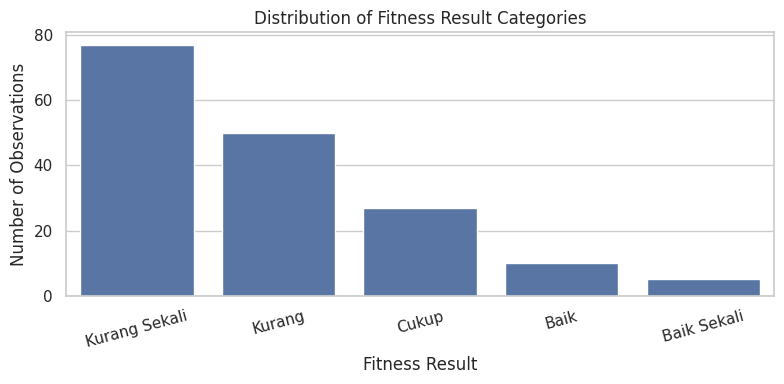

In [55]:
plt.figure(figsize=(8, 4))

order = data["Hasil"].value_counts().index
sns.countplot(data=data, x="Hasil", order=order)

plt.title("Distribution of Fitness Result Categories")
plt.xlabel("Fitness Result")
plt.ylabel("Number of Observations")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

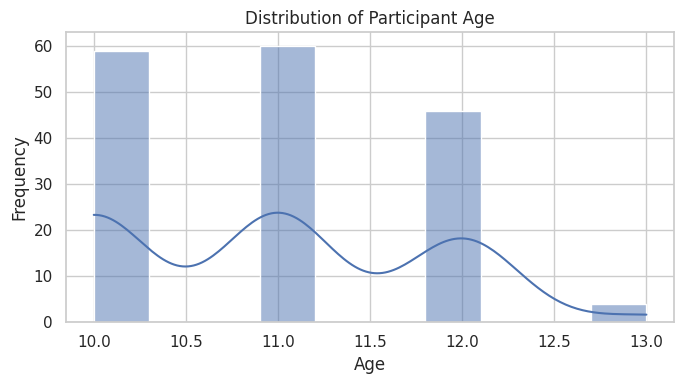

In [56]:
plt.figure(figsize=(7, 4))

sns.histplot(data=data, x="Umur", bins=10, kde=True)

plt.title("Distribution of Participant Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 5. Define Predictors and Target

In [57]:
# Predictors used in the original classification model
FEATURES = ["Umur", "Jenis Kelamin", "Waktu"]
TARGET = "Hasil"

X = df[FEATURES].copy()
y_raw = df[TARGET].copy()

print("Predictors:", FEATURES)
print("Target:", TARGET)

Predictors: ['Umur', 'Jenis Kelamin', 'Waktu']
Target: Hasil


### Encode Categorical Variables

In [58]:
gender_encoder = LabelEncoder()
target_encoder = LabelEncoder()

X["Jenis Kelamin"] = gender_encoder.fit_transform(X["Jenis Kelamin"])
y = target_encoder.fit_transform(y_raw)

print("Gender mapping:")
display(
    pd.DataFrame({
        "Original": gender_encoder.classes_,
        "Encoded": gender_encoder.transform(gender_encoder.classes_)
    })
)

print("\nTarget mapping:")
display(
    pd.DataFrame({
        "Original": target_encoder.classes_,
        "Encoded": target_encoder.transform(target_encoder.classes_)
    })
)

Gender mapping:


,Original,Encoded
0,L,0
1,P,1



Target mapping:


,Original,Encoded
0,Baik,0
1,Baik Sekali,1
2,Cukup,2
3,Kurang,3
4,Kurang Sekali,4


## 6. Stratified Train-Test Split

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Training observations: {len(X_train)}")
print(f"Test observations: {len(X_test)}")

print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts().sort_index())

Training observations: 135
Test observations: 34

Training class distribution:
0     8
1     4
2    22
3    40
4    61
Name: count, dtype: int64


## 7. Build Leakage-Safe Modeling Pipelines

SMOTE is placed **inside each modeling pipeline**.

This is important because synthetic observations should be generated only from the training portion of each cross-validation fold. Applying SMOTE before cross-validation can allow information from validation folds to influence the synthetic training data.

The pipeline is:

```text
Training fold
    ↓
RobustScaler
    ↓
SMOTE
    ↓
Classifier
```

The same structure is then used consistently for model comparison.

In [60]:
def make_pipeline(model):
    return Pipeline([
        ("scaler", RobustScaler()),
        ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=2)),
        ("model", model)
    ])


models = {
    "Decision Tree": DecisionTreeClassifier(
        criterion="entropy",
        max_depth=5,
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=500,
        random_state=RANDOM_STATE
    ),
    "XGBoost": xgb.XGBClassifier(
        eval_metric="mlogloss",
        random_state=RANDOM_STATE
    )
}

pipelines = {
    name: make_pipeline(model)
    for name, model in models.items()
}

## 8. Stratified 4-Fold Cross-Validation

In [61]:
cv = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "f1_weighted": make_scorer(f1_score, average="weighted")
}

cv_results = []

for name, pipeline in pipelines.items():
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
        error_score="raise"
    )

    cv_results.append({
        "Model": name,
        "Mean Accuracy": scores["test_accuracy"].mean(),
        "SD Accuracy": scores["test_accuracy"].std(),
        "Mean F1": scores["test_f1_weighted"].mean(),
        "SD F1": scores["test_f1_weighted"].std()
    })

cv_df = (
    pd.DataFrame(cv_results)
    .sort_values("Mean F1", ascending=False)
    .reset_index(drop=True)
)

display(cv_df)

,Model,Mean Accuracy,SD Accuracy,Mean F1,SD F1
0,Random Forest,0.888592,0.026084,0.877023,0.028273
1,XGBoost,0.845365,0.078498,0.842260,0.081485
2,KNN,0.800134,0.042880,0.798148,0.039158
3,Logistic Regression,0.771168,0.109903,0.779804,0.103840
4,Decision Tree,0.778075,0.031124,0.774049,0.034483


## 9. Train Models and Evaluate on the Held-Out Test Set

In [62]:
test_results = []
fitted_models = {}
test_predictions = {}

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    fitted_models[name] = pipeline
    test_predictions[name] = y_pred

    test_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Weighted F1": f1_score(
            y_test,
            y_pred,
            average="weighted"
        )
    })

test_results_df = (
    pd.DataFrame(test_results)
    .sort_values(["Weighted F1", "Accuracy"], ascending=False)
    .reset_index(drop=True)
)

display(test_results_df)

,Model,Accuracy,Weighted F1
0,Random Forest,0.882353,0.884836
1,KNN,0.882353,0.859151
2,Logistic Regression,0.823529,0.827028
3,XGBoost,0.823529,0.804251
4,Decision Tree,0.676471,0.679043


## 10. Model Comparison

In [63]:
comparison_df = cv_df.merge(
    test_results_df,
    on="Model",
    how="left"
)

display(comparison_df)

,Model,Mean Accuracy,SD Accuracy,Mean F1,SD F1,Accuracy,Weighted F1
0,Random Forest,0.888592,0.026084,0.877023,0.028273,0.882353,0.884836
1,XGBoost,0.845365,0.078498,0.842260,0.081485,0.823529,0.804251
2,KNN,0.800134,0.042880,0.798148,0.039158,0.882353,0.859151
3,Logistic Regression,0.771168,0.109903,0.779804,0.103840,0.823529,0.827028
4,Decision Tree,0.778075,0.031124,0.774049,0.034483,0.676471,0.679043


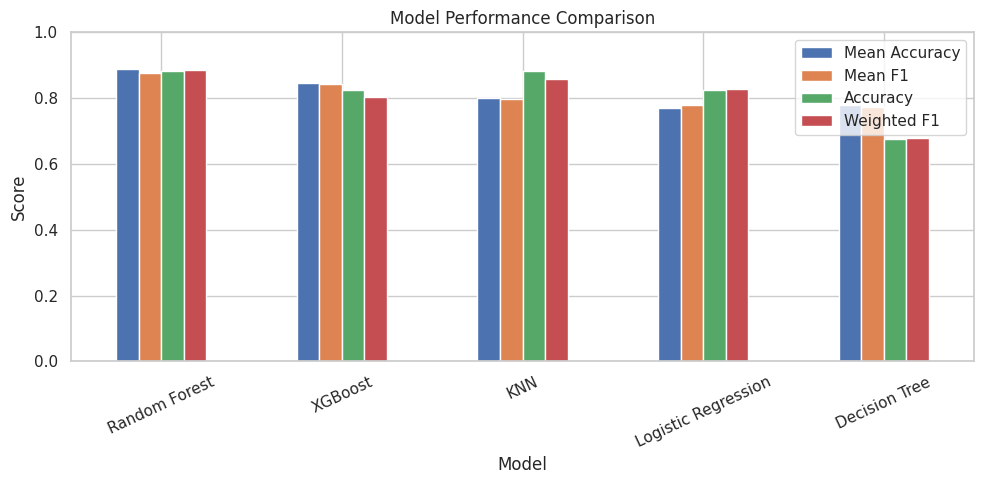

In [64]:
plot_df = comparison_df.set_index("Model")[[
    "Mean Accuracy",
    "Mean F1",
    "Accuracy",
    "Weighted F1"
]]

plot_df.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=25)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 11. Select the Model

For this portfolio workflow, the model with the highest cross-validation weighted F1-score is selected for the subsequent interpretation step.

This selection rule is explicit and reproducible rather than relying only on a single test-set result.

In [65]:
best_model_name = cv_df.iloc[0]["Model"]
best_pipeline = fitted_models[best_model_name]
best_predictions = test_predictions[best_model_name]

print(f"Selected model: {best_model_name}")
print(
    f"Cross-validation mean weighted F1: "
    f"{cv_df.iloc[0]['Mean F1']:.4f}"
)
print(
    f"Held-out test weighted F1: "
    f"{f1_score(y_test, best_predictions, average='weighted'):.4f}"
)

Selected model: Random Forest
Cross-validation mean weighted F1: 0.8770
Held-out test weighted F1: 0.8848


## 12. Classification Report

In [66]:
print(
    classification_report(
        y_test,
        best_predictions,
        target_names=target_encoder.classes_,
        zero_division=0
    )
)

               precision    recall  f1-score   support

         Baik       1.00      0.50      0.67         2
  Baik Sekali       1.00      1.00      1.00         1
        Cukup       0.62      1.00      0.77         5
       Kurang       0.89      0.80      0.84        10
Kurang Sekali       1.00      0.94      0.97        16

     accuracy                           0.88        34
    macro avg       0.90      0.85      0.85        34
 weighted avg       0.91      0.88      0.88        34



## 13. Confusion Matrix

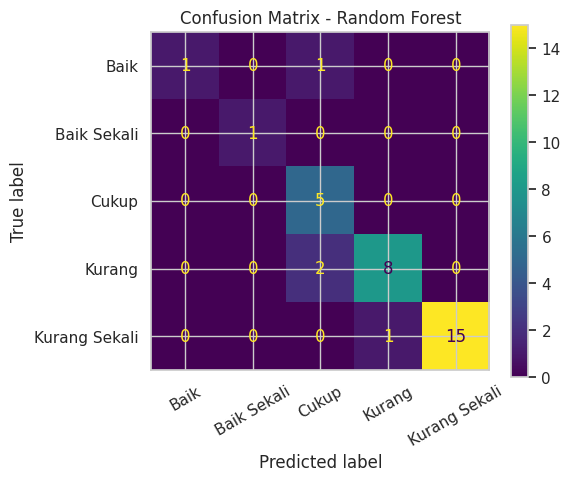

In [67]:
cm = confusion_matrix(y_test, best_predictions)

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_encoder.classes_
)

disp.plot(
    values_format="d",
    ax=ax,
    xticks_rotation=30
)

ax.set_title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()

## 14. Feature Importance

,Feature,Importance
2,Waktu,0.626189
0,Umur,0.265101
1,Jenis Kelamin,0.108710


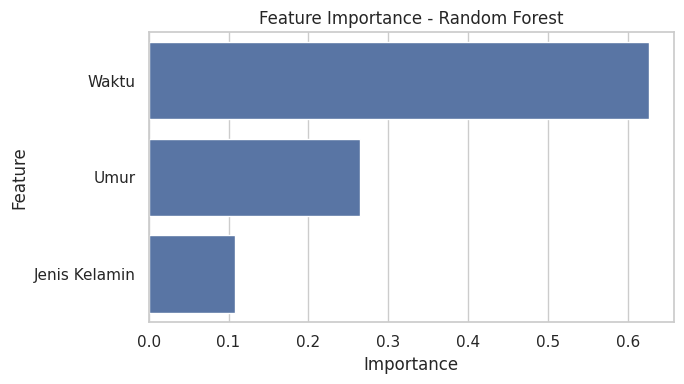

In [68]:
# Feature importance is available for tree-based models.
if best_model_name in {"Decision Tree", "Random Forest", "XGBoost"}:
    fitted_estimator = best_pipeline.named_steps["model"]

    feature_importance = pd.DataFrame({
        "Feature": FEATURES,
        "Importance": fitted_estimator.feature_importances_
    }).sort_values("Importance", ascending=False)

    display(feature_importance)

    plt.figure(figsize=(7, 4))

    sns.barplot(
        data=feature_importance,
        x="Importance",
        y="Feature"
    )

    plt.title(f"Feature Importance - {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

else:
    print(
        f"Feature importance is not directly available for "
        f"{best_model_name}."
    )

## 15. Example Predictions

In [69]:
prediction_sample = X_test.copy()
prediction_sample["Actual"] = target_encoder.inverse_transform(y_test)
prediction_sample["Prediction"] = target_encoder.inverse_transform(
    best_predictions
)

display(prediction_sample.head(10))

,Umur,Jenis Kelamin,Waktu,Actual,Prediction
163,10,0,7.50,Kurang,Kurang
68,11,1,7.54,Kurang,Kurang
60,11,0,11.23,Kurang Sekali,Kurang Sekali
12,10,1,8.33,Kurang,Kurang
0,10,1,10.12,Kurang Sekali,Kurang Sekali
55,10,0,9.34,Kurang Sekali,Kurang Sekali
136,10,0,8.13,Kurang Sekali,Kurang Sekali
143,11,0,6.24,Kurang,Cukup
33,12,0,5.11,Cukup,Cukup
123,12,0,5.03,Baik,Cukup


## 16. Conclusion

This project demonstrates an end-to-end multiclass classification workflow for physical fitness data.

Key steps include:

- Exploratory data analysis
- Data quality checking
- Categorical encoding
- Stratified train-test splitting
- Robust scaling
- Leakage-safe SMOTE implementation
- Comparison of five classification algorithms
- Stratified 5-fold cross-validation
- Held-out test-set evaluation
- Confusion matrix analysis
- Feature-importance interpretation

### Reproducibility

The main modeling choices use a fixed `random_state=42` where applicable. Model performance should be interpreted as specific to the available dataset, preprocessing choices, and evaluation design.

### Portfolio Note

This notebook focuses on the analytical and machine-learning workflow. Any exercise recommendations from the original project should be treated as project-specific outputs rather than medical or clinical advice.